In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.metrics import roc_auc_score, brier_score_loss

from river import tree, model_selection, utils, metrics, stream
from river.compat import convert_river_to_sklearn

import itertools

import json
import sys
import warnings

from collections import Counter
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from math import log2
from pathlib import Path
from time import perf_counter
from typing import Iterator, Sequence

import time

from __future__ import annotations

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
miniboone = fetch_openml(data_id=41150, as_frame=True, parser='auto')

# Extract features and targets
X = miniboone.data
y = miniboone.target

In [3]:
X.info()

#no null values
#all features are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130064 entries, 0 to 130063
Data columns (total 50 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ParticleID_0   130064 non-null  float64
 1   ParticleID_1   130064 non-null  float64
 2   ParticleID_2   130064 non-null  float64
 3   ParticleID_3   130064 non-null  float64
 4   ParticleID_4   130064 non-null  float64
 5   ParticleID_5   130064 non-null  float64
 6   ParticleID_6   130064 non-null  float64
 7   ParticleID_7   130064 non-null  float64
 8   ParticleID_8   130064 non-null  float64
 9   ParticleID_9   130064 non-null  float64
 10  ParticleID_10  130064 non-null  float64
 11  ParticleID_11  130064 non-null  float64
 12  ParticleID_12  130064 non-null  float64
 13  ParticleID_13  130064 non-null  float64
 14  ParticleID_14  130064 non-null  float64
 15  ParticleID_15  130064 non-null  float64
 16  ParticleID_16  130064 non-null  float64
 17  ParticleID_17  130064 non-nul

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=5)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=5)

---
# Definition of a Data Pass

> One data pass is one complete sequential traversal of the training split, during which each training observation is read exactly once for a specified learning stage. Validation/test evaluation is not counted as a training pass. Computation performed from already accumulated in-memory statistics does not add another pass.

| Model | Learner passes | Learning stages | Preprocessing passes | Total pipeline passes |
| --- | ---: | --- | ---: | ---: |
| Hoeffding Tree | One per completed stream traversal | One call to `learn_one` for each of the $N$ training rows | 0 | Same as learner passes |
| Naive Bayes | 1 | Class and feature-conditional sufficient statistics | 1 | **2** |
| KDB | 2 | MI/CMI structure statistics; then sparse CPT parameters | 1 | **3** |
| Selective KDB | 3 | Structure; complete family counts; incremental LOOCV selection | 1 | **4** |

The Bayesian models share one supervised Fayyad-Irani-style MDL representation fitted from `X_train/y_train` only. Learned cuts are applied on the fly during learner passes. Missing values have a separate categorical state. The validation and test splits never determine cut points or update a model.

RF tree counts and XGBoost rounds in the earlier notebook are algorithm-native nominal units, not verified complete data traversals. They are intentionally excluded from the genuine full-data-pass graphs below.

---

### Hoeffding Tree


#### Hyperparameter tuning & its results:

In [5]:
ht_param_grid = {
    'grace_period': [50, 75, 100,125,150], 
    'max_depth': [1,2,3], 
    'split_criterion': ['gini', 'info_gain', 'hellinger'],
    'leaf_prediction': ['mc', 'nb', 'nba'],
    "delta": [1e-5, 1e-7, 1e-9],
    "tau": [0.01, 0.05, 0.1]
}

def HT_hyperparam_tuning(budget, X_train, y_train, ht_param_grid=ht_param_grid):


    keys, values = zip(*ht_param_grid.items())
    combinations=[dict(zip(keys, v)) for v in itertools.product(*values)]
    
    models=[
        tree.HoeffdingTreeClassifier(**params)
        for params in combinations
    ]
    
    
    grid_search_stream = model_selection.SuccessiveHalvingClassifier(
        models=models,
        budget=budget, 
        eta=3,
        verbose=True,
        metric=metrics.ROCAUC(
            pos_val="2",
            n_thresholds=100,
        )
    )
    
    for xi_dict, yi in stream.iter_array(X_train.values, y_train.values):
        grid_search_stream.learn_one(xi_dict, yi)
    
    #getting the best model
    best_model = grid_search_stream.best_model
    print("\n" + "="*50)
    print("TUNING COMPLETE")
    print("Best Found Tree Configuration:")
    print(f"Grace Period: {best_model.grace_period}")
    print(f"Max Depth: {best_model.max_depth}")
    print(f"Split Criterion: {best_model.split_criterion}")
    print(f"Leaf Prediction Strategy: {best_model.leaf_prediction}")
    print(f"Delta:{best_model.delta}")
    print(f"Tau:{best_model.tau}")

    return best_model


In [6]:
def HT_hyperparam_val(POSITIVE_CLASS, X_val, y_val, best_model):

    validation_probabilities = []
    validation_targets = []
    
    validation_stream = stream.iter_array(
        X_val.to_numpy(),
        y_val.astype(str).to_numpy(),
    )
    
    for x_dict, y_true in validation_stream:
        probability_dict = best_model.predict_proba_one(x_dict)
    
        if POSITIVE_CLASS not in probability_dict:
            raise KeyError(
                f"Model did not return probability for class "
                f"{POSITIVE_CLASS!r}. Returned: {probability_dict}"
            )
    
        validation_probabilities.append(
            float(probability_dict[POSITIVE_CLASS])
        )
    
        validation_targets.append(
            int(y_true == POSITIVE_CLASS)
        )
    
    validation_probabilities = np.asarray(
        validation_probabilities,
        dtype=float,
    )
    
    validation_targets = np.asarray(
        validation_targets,
        dtype=int,
    )
    
    validation_auc = roc_auc_score(
        validation_targets,
        validation_probabilities,
    )
    
    print("Validation ROC-AUC:", validation_auc)
    print(
        "Probability range:",
        validation_probabilities.min(),
        validation_probabilities.max(),
    )
    print(
        "Probability standard deviation:",
        validation_probabilities.std(),
    )
    print(
        "Number of unique probabilities:",
        np.unique(
            np.round(validation_probabilities, decimals=10)
        ).size,
    )

#### Training a fresh model

In [7]:
FINAL_HT_PARAMS = {
    "grace_period": 50,
    "max_depth": 1,
    "split_criterion": "gini",
    "leaf_prediction": "mc",
    "delta": 1e-5,
    "tau": 0.01,
}

POSITIVE_CLASS = "True"

In [8]:
#preparing the train and val sets:

FEATURE_NAMES = list(X_train.columns)

X_train_array = X_train.to_numpy()
y_train_array = y_train.astype(str).to_numpy()

X_val_array = X_val.to_numpy()
y_val_array = y_val.astype(str).to_numpy()

In [9]:
#eval function
def evaluate_hoeffding_tree(
    model,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
) -> dict:
    """Evaluate a River classifier using exact binary ROC-AUC."""

    probabilities = []
    binary_targets = []

    evaluation_stream = stream.iter_array(
        X_eval,
        y_eval,
        feature_names=FEATURE_NAMES,
        shuffle=False,
    )

    for row_number, (x_dict, y_true) in enumerate(
        evaluation_stream
    ):
        probability_dict = model.predict_proba_one(x_dict)

        if POSITIVE_CLASS not in probability_dict:
            raise KeyError(
                f"Positive class {POSITIVE_CLASS!r} missing "
                f"at evaluation row {row_number}. "
                f"Returned probabilities: {probability_dict}"
            )

        positive_probability = float(
            probability_dict[POSITIVE_CLASS]
        )

        probabilities.append(positive_probability)
        binary_targets.append(
            int(y_true == POSITIVE_CLASS)
        )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    binary_targets = np.asarray(
        binary_targets,
        dtype=int,
    )

    auc = roc_auc_score(
        binary_targets,
        probabilities,
    )

    brier = brier_score_loss(
        binary_targets,
        probabilities,
    )

    return {
        "roc_auc": float(auc),
        "brier_score": float(brier),
        "probability_rmse": float(np.sqrt(brier)),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
        "unique_probabilities": int(
            np.unique(
                np.round(probabilities, decimals=12)
            ).size
        ),
    }

In [10]:
#shuffling dataset once:
CHECKPOINTS = list(range(1, 11))
MAX_PASSES = max(CHECKPOINTS)
ORDER_SEED = 42

rng = np.random.default_rng(ORDER_SEED)
training_order = rng.permutation(
    len(X_train_array)
)

X_train_ordered = X_train_array[training_order]
y_train_ordered = y_train_array[training_order]

In [11]:
#creating a fresh model:
ht_model = tree.HoeffdingTreeClassifier(
    **FINAL_HT_PARAMS
)

In [12]:
#running the passes:
ht_pass_results = []

cumulative_training_seconds = 0.0
cumulative_evaluation_seconds = 0.0
rows_processed = 0

for pass_number in range(1, MAX_PASSES + 1):

    # ---------------------------
    # One complete training pass
    # ---------------------------
    training_start = time.perf_counter()

    training_stream = stream.iter_array(
        X_train_ordered,
        y_train_ordered,
        feature_names=FEATURE_NAMES,
        shuffle=False,
    )

    for x_dict, y_true in training_stream:
        ht_model.learn_one(x_dict, y_true)
        rows_processed += 1

    pass_training_seconds = (
        time.perf_counter() - training_start
    )

    cumulative_training_seconds += (
        pass_training_seconds
    )

    if pass_number not in CHECKPOINTS:
        continue

    # ---------------------------
    # Validation evaluation
    # ---------------------------
    evaluation_start = time.perf_counter()

    evaluation = evaluate_hoeffding_tree(
        ht_model,
        X_val_array,
        y_val_array,
    )

    pass_evaluation_seconds = (
        time.perf_counter() - evaluation_start
    )

    cumulative_evaluation_seconds += (
        pass_evaluation_seconds
    )

    result = {
        "model": "Hoeffding Tree",
        "pass": pass_number,
        "rows_processed": rows_processed,
        "roc_auc": evaluation["roc_auc"],
        "brier_score": evaluation["brier_score"],
        "probability_rmse":
            evaluation["probability_rmse"],
        "unique_probabilities":
            evaluation["unique_probabilities"],
        "probability_min":
            evaluation["probability_min"],
        "probability_max":
            evaluation["probability_max"],
        "pass_training_seconds":
            pass_training_seconds,
        "cumulative_training_seconds":
            cumulative_training_seconds,
        "pass_evaluation_seconds":
            pass_evaluation_seconds,
        "cumulative_evaluation_seconds":
            cumulative_evaluation_seconds,
        "tree_height": getattr(
            ht_model,
            "height",
            None,
        ),
        "n_nodes": getattr(
            ht_model,
            "n_nodes",
            None,
        ),
        "n_leaves": getattr(
            ht_model,
            "n_leaves",
            None,
        ),
    }

    ht_pass_results.append(result)

    print(
        f"Pass {pass_number:>2} | "
        f"AUC={evaluation['roc_auc']:.6f} | "
        f"RMSE={evaluation['probability_rmse']:.6f} | "
        f"rows={rows_processed:,} | "
        f"train time={cumulative_training_seconds:.2f}s"
    )

Pass  1 | AUC=0.687026 | RMSE=0.392473 | rows=78,038 | train time=1.67s
Pass  2 | AUC=0.687026 | RMSE=0.392473 | rows=156,076 | train time=3.22s
Pass  3 | AUC=0.687026 | RMSE=0.392473 | rows=234,114 | train time=4.69s
Pass  4 | AUC=0.687026 | RMSE=0.392472 | rows=312,152 | train time=6.05s
Pass  5 | AUC=0.687026 | RMSE=0.392472 | rows=390,190 | train time=7.41s
Pass  6 | AUC=0.687026 | RMSE=0.392472 | rows=468,228 | train time=8.80s
Pass  7 | AUC=0.687026 | RMSE=0.392472 | rows=546,266 | train time=10.17s
Pass  8 | AUC=0.687026 | RMSE=0.392472 | rows=624,304 | train time=11.44s
Pass  9 | AUC=0.687026 | RMSE=0.392472 | rows=702,342 | train time=12.90s
Pass 10 | AUC=0.687026 | RMSE=0.392472 | rows=780,380 | train time=14.54s


In [13]:
ht_pass_results_df = pd.DataFrame(
    ht_pass_results
)

display(ht_pass_results_df)

,model,pass,rows_processed,roc_auc,brier_score,probability_rmse,unique_probabilities,probability_min,probability_max,pass_training_seconds,cumulative_training_seconds,pass_evaluation_seconds,cumulative_evaluation_seconds,tree_height,n_nodes,n_leaves
0,Hoeffding Tree,1,78038,0.687026,0.154035,0.392473,2,0.193047,0.829741,1.669559,1.669559,0.754875,0.754875,2,3,2
1,Hoeffding Tree,2,156076,0.687026,0.154035,0.392473,2,0.193161,0.829277,1.553888,3.223447,0.746909,1.501783,2,3,2
2,Hoeffding Tree,3,234114,0.687026,0.154035,0.392473,2,0.193200,0.829121,1.462235,4.685683,0.777806,2.279589,2,3,2
3,Hoeffding Tree,4,312152,0.687026,0.154035,0.392472,2,0.193219,0.829044,1.363175,6.048858,0.720759,3.000348,2,3,2
4,Hoeffding Tree,5,390190,0.687026,0.154035,0.392472,2,0.193230,0.828997,1.362099,7.410956,0.732780,3.733127,2,3,2
5,Hoeffding Tree,6,468228,0.687026,0.154035,0.392472,2,0.193238,0.828966,1.385298,8.796254,0.773963,4.507091,2,3,2
6,Hoeffding Tree,7,546266,0.687026,0.154035,0.392472,2,0.193243,0.828944,1.375485,10.171739,0.723253,5.230344,2,3,2
7,Hoeffding Tree,8,624304,0.687026,0.154035,0.392472,2,0.193248,0.828928,1.264838,11.436577,0.706206,5.936551,2,3,2
8,Hoeffding Tree,9,702342,0.687026,0.154035,0.392472,2,0.193251,0.828915,1.467207,12.903784,0.889734,6.826284,2,3,2
9,Hoeffding Tree,10,780380,0.687026,0.154035,0.392472,2,0.193253,0.828904,1.633900,14.537684,0.779659,7.605943,2,3,2


In [14]:
#saving results in a csv: 

ht_pass_results_df.to_csv(
    "Skin dataset outputs/hoeffding_tree_pass_results.csv",
    index=False,
)

In [15]:
def pass_roc_plot(df, model_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        df["pass"],
        df["roc_auc"],
        marker="o",
    )
    
    plt.xlabel("Number of complete training passes")
    plt.ylabel("Validation ROC-AUC")
    plt.title(f"{model_name}: ROC-AUC vs Training Passes")
    plt.xticks(CHECKPOINTS)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

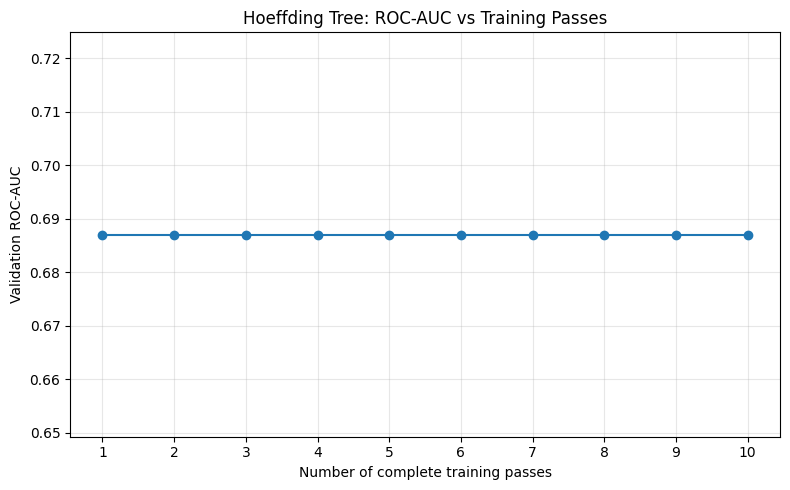

In [16]:
pass_roc_plot(df=ht_pass_results_df, model_name='Hoeffding Tree')

## Naive Bayes, KDB and Selective KDB

### Pass tracking

Every learner stage below consumes rows through the same checked sequential iterator. A declared full pass raises an error unless it reads exactly `N_train` observations.


In [17]:
"""Auditable full-training-pass accounting.

Definition of a Data Pass
-------------------------
One data pass is one complete sequential traversal of the training split,
during which each training observation is read exactly once for a specified
learning stage. Validation/test evaluation is not counted as a training pass.
Computation performed from already accumulated in-memory statistics does not
add another pass.
"""

@dataclass(frozen=True)
class PassRecord:
    """One verified complete traversal of the training split."""

    model: str
    stage: str
    pass_type: str
    learner_pass_number: int | None
    rows_read: int
    expected_rows: int
    seconds: float


class PassTracker:
    """Record full passes and fail if a stage does not read exactly N rows."""

    def __init__(self, expected_rows: int) -> None:
        if expected_rows <= 0:
            raise ValueError("expected_rows must be positive")
        self.expected_rows = int(expected_rows)
        self.records: list[PassRecord] = []

    @contextmanager
    def iter_training_rows(
        self,
        X: Sequence,
        y: Sequence,
        *,
        model: str,
        stage: str,
        pass_type: str,
        learner_pass_number: int | None,
        progress: bool = False,
    ) -> Iterator[Iterator[tuple[object, object]]]:
        """Yield a single-use sequential row iterator for one declared pass."""

        if len(X) != self.expected_rows or len(y) != self.expected_rows:
            raise ValueError(
                "Training split length changed: "
                f"expected {self.expected_rows}, got X={len(X)}, y={len(y)}"
            )

        rows_read = 0
        next_progress = 25
        started = perf_counter()

        def row_iterator() -> Iterator[tuple[object, object]]:
            nonlocal rows_read, next_progress
            for row_number in range(self.expected_rows):
                rows_read += 1
                if progress:
                    percent = (100 * rows_read) // self.expected_rows
                    if percent >= next_progress:
                        print(
                            f"[{model}] {stage} — {min(next_progress, 100)}%"
                        )
                        next_progress += 25
                yield X[row_number], y[row_number]

        yield row_iterator()

        seconds = perf_counter() - started
        if rows_read != self.expected_rows:
            raise RuntimeError(
                f"{model} / {stage} read {rows_read} training rows; "
                f"expected exactly {self.expected_rows}."
            )

        self.records.append(
            PassRecord(
                model=model,
                stage=stage,
                pass_type=pass_type,
                learner_pass_number=learner_pass_number,
                rows_read=rows_read,
                expected_rows=self.expected_rows,
                seconds=float(seconds),
            )
        )

    def rows_read(self, pass_type: str | None = None) -> int:
        records = self.records
        if pass_type is not None:
            records = [r for r in records if r.pass_type == pass_type]
        return int(sum(r.rows_read for r in records))

    def pass_count(self, pass_type: str | None = None) -> int:
        if pass_type is None:
            return len(self.records)
        return sum(r.pass_type == pass_type for r in self.records)

    def to_records(self) -> list[dict[str, object]]:
        return [asdict(record) for record in self.records]


### Shared supervised MDL discretisation

Cut points use `X_train/y_train` only. Applying the learned cuts during each learner pass does not create an additional pass.


In [18]:
"""Training-only supervised Fayyad-Irani-style MDL discretisation."""

def _entropy(counts: np.ndarray) -> float:
    total = int(counts.sum())
    if total == 0:
        return 0.0
    probabilities = counts[counts > 0] / total
    return float(-np.sum(probabilities * np.log2(probabilities)))


def _mdl_cut_points(values: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Return recursively accepted MDL cuts for one numeric feature."""

    if values.size < 2 or np.unique(labels).size < 2:
        return np.empty(0, dtype=np.float64)

    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]
    sorted_labels = labels[order]
    n_classes = int(sorted_labels.max()) + 1
    accepted: list[float] = []

    def split(start: int, stop: int) -> None:
        n = stop - start
        if n < 2:
            return

        node_labels = sorted_labels[start:stop]
        total_counts = np.bincount(node_labels, minlength=n_classes)
        parent_entropy = _entropy(total_counts)
        if parent_entropy == 0.0:
            return

        left_counts = np.zeros(n_classes, dtype=np.int64)
        best_position: int | None = None
        best_weighted_entropy = np.inf

        # All boundaries between distinct observed values are valid candidates.
        # Cumulative counts make this linear for each recursive interval.
        for position in range(start, stop - 1):
            left_counts[sorted_labels[position]] += 1
            if sorted_values[position] == sorted_values[position + 1]:
                continue

            n_left = position - start + 1
            n_right = n - n_left
            right_counts = total_counts - left_counts
            weighted_entropy = (
                n_left * _entropy(left_counts)
                + n_right * _entropy(right_counts)
            ) / n

            if weighted_entropy < best_weighted_entropy:
                best_weighted_entropy = weighted_entropy
                best_position = position

        if best_position is None:
            return

        n_left = best_position - start + 1
        left = np.bincount(
            sorted_labels[start : best_position + 1], minlength=n_classes
        )
        right = total_counts - left
        gain = parent_entropy - best_weighted_entropy

        k = int(np.count_nonzero(total_counts))
        k_left = int(np.count_nonzero(left))
        k_right = int(np.count_nonzero(right))
        delta = log2((3**k) - 2) - (
            k * parent_entropy
            - k_left * _entropy(left)
            - k_right * _entropy(right)
        )
        threshold = (log2(n - 1) + delta) / n if n > 1 else np.inf

        if gain <= threshold:
            return

        low = float(sorted_values[best_position])
        high = float(sorted_values[best_position + 1])
        cut = low + (high - low) / 2.0
        accepted.append(cut)
        split(start, best_position + 1)
        split(best_position + 1, stop)

    split(0, sorted_values.size)
    return np.asarray(sorted(accepted), dtype=np.float64)


class MDLDiscretizer:
    """Supervised MDL bins fitted in exactly one training-data traversal.

    Non-finite values (NaN and +/- infinity) are assigned to a dedicated state
    and never participate in cut-point estimation.
    """

    method_name = "Fayyad-Irani supervised MDL (training split only)"

    def __init__(self) -> None:
        self.cut_points_: list[np.ndarray] | None = None
        self.cardinalities_: np.ndarray | None = None
        self.fit_seconds_: float = 0.0
        self.pass_tracker_: PassTracker | None = None

    def fit(
        self,
        X: Sequence,
        y: Sequence,
        *,
        tracker: PassTracker | None = None,
        progress: bool = False,
    ) -> "MDLDiscretizer":
        X_array = np.asarray(X)
        y_array = np.asarray(y, dtype=object).reshape(-1)
        if X_array.ndim != 2:
            raise ValueError("X must be a two-dimensional numeric matrix")
        if len(X_array) != len(y_array):
            raise ValueError("X and y must have the same number of rows")

        try:
            X_numeric = X_array.astype(np.float64, copy=False)
        except (TypeError, ValueError) as exc:
            raise TypeError("MDLDiscretizer requires numeric features") from exc

        labels_as_strings = np.asarray([str(value) for value in y_array])
        classes = sorted(set(labels_as_strings.tolist()))
        label_to_index = {label: i for i, label in enumerate(classes)}
        encoded_y = np.asarray(
            [label_to_index[label] for label in labels_as_strings],
            dtype=np.int32,
        )

        n_rows, n_features = X_numeric.shape
        tracker = tracker or PassTracker(n_rows)
        started = perf_counter()
        # Dense temporary numeric storage is bounded at O(N*d), avoids millions
        # of Python float/int objects on MiniBooNE, and is filled only inside the
        # declared preprocessing traversal. Labels are stored once, not per
        # feature. Both buffers are released when fit returns.
        value_buffer = np.empty((n_rows, n_features), dtype=np.float64)
        label_buffer = np.empty(n_rows, dtype=np.int32)
        with tracker.iter_training_rows(
            X_numeric,
            encoded_y,
            model="Shared MDL Discretizer",
            stage="supervised MDL cut-point fit",
            pass_type="preprocessing",
            learner_pass_number=None,
            progress=progress,
        ) as rows:
            for row_number, (row, class_index) in enumerate(rows):
                value_buffer[row_number] = row
                label_buffer[row_number] = int(class_index)

        self.cut_points_ = []
        for feature_index in range(n_features):
            observed = np.isfinite(value_buffer[:, feature_index])
            self.cut_points_.append(
                _mdl_cut_points(
                    value_buffer[observed, feature_index],
                    label_buffer[observed],
                )
            )

        # Observed bins plus one permanently reserved missing-value state.
        self.cardinalities_ = np.asarray(
            [len(cuts) + 2 for cuts in self.cut_points_], dtype=np.int32
        )
        self.fit_seconds_ = float(perf_counter() - started)
        self.pass_tracker_ = tracker
        return self

    def _check_fitted(self) -> None:
        if self.cut_points_ is None or self.cardinalities_ is None:
            raise RuntimeError("The MDL discretizer has not been fitted")

    def transform_row(self, row: Sequence) -> np.ndarray:
        self._check_fitted()
        numeric_row = np.asarray(row, dtype=np.float64).reshape(-1)
        if len(numeric_row) != len(self.cut_points_):
            raise ValueError("Row feature count does not match fitted discretizer")

        states = np.empty(len(numeric_row), dtype=np.int32)
        for feature_index, value in enumerate(numeric_row):
            cuts = self.cut_points_[feature_index]
            if np.isfinite(value):
                states[feature_index] = int(
                    np.searchsorted(cuts, value, side="right")
                )
            else:
                states[feature_index] = len(cuts) + 1
        return states

    def transform(self, X: Sequence) -> np.ndarray:
        """Transform evaluation data; this never fits or changes cut points."""
        X_array = np.asarray(X)
        return np.vstack([self.transform_row(row) for row in X_array])


### Shared external evaluation metrics

ROC-AUC is calculated from positive-class probabilities, never hard labels. Accuracy and 0-1 error are reported as secondary metrics.


In [19]:
"""Shared exact binary probability metrics for every classifier."""

def make_binary_labels(y, positive_class: object) -> np.ndarray:
    labels = np.asarray(y, dtype=object).reshape(-1)
    positive = str(positive_class)
    return np.asarray([int(str(label) == positive) for label in labels], dtype=np.int8)


def evaluate_binary_probabilities(
    y_true,
    positive_probabilities,
    *,
    positive_class: object,
) -> dict[str, float | int]:
    """Calculate exact ROC-AUC and shared probabilistic metrics."""

    binary_targets = make_binary_labels(y_true, positive_class)
    probabilities = np.asarray(positive_probabilities, dtype=np.float64)
    if binary_targets.shape != probabilities.shape:
        raise ValueError(
            f"Shape mismatch: labels={binary_targets.shape}, "
            f"probabilities={probabilities.shape}"
        )
    if not np.all(np.isfinite(probabilities)):
        raise ValueError("Predictions contain NaN or infinite values")
    if np.any((probabilities < 0.0) | (probabilities > 1.0)):
        raise ValueError("Predicted probabilities must lie in [0, 1]")
    if np.unique(binary_targets).size != 2:
        raise ValueError("ROC-AUC requires both classes in the evaluation split")

    brier = float(brier_score_loss(binary_targets, probabilities))
    predicted = (probabilities >= 0.5).astype(np.int8)
    accuracy = float(np.mean(predicted == binary_targets))
    return {
        "roc_auc": float(roc_auc_score(binary_targets, probabilities)),
        "brier_score": brier,
        "probability_rmse": float(np.sqrt(brier)),
        "accuracy": accuracy,
        "zero_one_error": float(1.0 - accuracy),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
        "unique_probabilities": int(
            np.unique(np.round(probabilities, decimals=12)).size
        ),
    }


### Shared categorical Bayesian-network machinery

This cell contains MI/CMI structure statistics, sparse CPT counting, shared smoothing, unseen-context handling and stable log-space prediction.


In [20]:
"""Shared sparse categorical Bayesian-network-classifier machinery."""

def _as_row_matrix(X: Sequence) -> np.ndarray:
    if hasattr(X, "to_numpy"):
        array = X.to_numpy(copy=False)
    else:
        array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be a two-dimensional matrix")
    return array


def _as_string_labels(y: Sequence) -> np.ndarray:
    values = np.asarray(y, dtype=object).reshape(-1)
    return np.asarray([str(value) for value in values], dtype=object)


def _normalise_log_scores(log_scores: np.ndarray) -> np.ndarray:
    maximum = float(np.max(log_scores))
    shifted = np.exp(log_scores - maximum)
    return shifted / shifted.sum()


def _recursive_size_bytes(value: object, seen: set[int] | None = None) -> int:
    """Best-effort size of sparse in-memory statistics, avoiding cycles."""
    seen = seen or set()
    object_id = id(value)
    if object_id in seen:
        return 0
    seen.add(object_id)
    size = sys.getsizeof(value)
    if isinstance(value, dict):
        size += sum(
            _recursive_size_bytes(key, seen) + _recursive_size_bytes(item, seen)
            for key, item in value.items()
        )
    elif isinstance(value, (list, tuple, set)):
        size += sum(_recursive_size_bytes(item, seen) for item in value)
    elif hasattr(value, "__dict__"):
        size += _recursive_size_bytes(vars(value), seen)
    return size


@dataclass
class StructureStatistics:
    class_counts: Counter
    feature_class_counts: list[Counter]
    pair_class_counts: dict[tuple[int, int], Counter]


@dataclass
class ParameterStatistics:
    class_counts: Counter
    conditional_counts: list[list[Counter]]
    context_counts: list[list[Counter]]
    n_rows: int


class CategoricalBNC:
    """Base implementation shared by NB, KDB and SKDB.

    Probabilities use additive smoothing and are accumulated in log space.
    Sparse counters contain observed state/context combinations only.
    """

    model_name = "Categorical BNC"

    def __init__(
        self,
        discretizer: MDLDiscretizer,
        *,
        alpha: float = 1.0,
    ) -> None:
        if alpha <= 0:
            raise ValueError("alpha must be positive")
        discretizer._check_fitted()
        self.discretizer = discretizer
        self.alpha = float(alpha)
        self.classes_: np.ndarray | None = None
        self.class_to_index_: dict[str, int] | None = None
        self.feature_order_: np.ndarray | None = None
        self.parent_rankings_: dict[int, tuple[int, ...]] | None = None
        self.mutual_information_: np.ndarray | None = None
        self.conditional_mutual_information_: np.ndarray | None = None
        self.structure_statistics_: StructureStatistics | None = None
        self.parameter_statistics_: ParameterStatistics | None = None
        self.pass_tracker_: PassTracker | None = None
        self.structure_pass_seconds_: float = 0.0
        self.parameter_pass_seconds_: float = 0.0
        self.selection_pass_seconds_: float = 0.0
        self.statistics_size_bytes_: int = 0
        self.max_counted_k_: int = 0

    @property
    def n_features_(self) -> int:
        return int(len(self.discretizer.cardinalities_))

    def _initialise_classes(self, y: Sequence) -> np.ndarray:
        string_labels = _as_string_labels(y)
        classes = sorted(set(string_labels.tolist()))
        if len(classes) < 2:
            raise ValueError("At least two training classes are required")
        self.classes_ = np.asarray(classes, dtype=object)
        self.class_to_index_ = {label: i for i, label in enumerate(classes)}
        return np.asarray(
            [self.class_to_index_[label] for label in string_labels],
            dtype=np.int32,
        )

    def _encode_existing_labels(self, y: Sequence) -> np.ndarray:
        if self.class_to_index_ is None:
            raise RuntimeError("Classes have not been initialised")
        labels = _as_string_labels(y)
        try:
            return np.asarray(
                [self.class_to_index_[label] for label in labels], dtype=np.int32
            )
        except KeyError as exc:
            raise ValueError(f"Unknown class label {exc.args[0]!r}") from exc

    def _fit_structure(
        self,
        X: Sequence,
        encoded_y: np.ndarray,
        *,
        tracker: PassTracker,
        max_k: int,
        progress: bool,
    ) -> None:
        if max_k < 0:
            raise ValueError("max_k cannot be negative")
        started = perf_counter()
        X_array = _as_row_matrix(X)
        n_features = self.n_features_
        class_counts: Counter = Counter()
        feature_class_counts = [Counter() for _ in range(n_features)]
        pair_class_counts = {
            (i, j): Counter()
            for i in range(n_features)
            for j in range(i + 1, n_features)
        }

        with tracker.iter_training_rows(
            X_array,
            encoded_y,
            model=self.model_name,
            stage="pass 1: structure statistics",
            pass_type="learner",
            learner_pass_number=1,
            progress=progress,
        ) as rows:
            for raw_row, class_index in rows:
                states = self.discretizer.transform_row(raw_row)
                class_index = int(class_index)
                class_counts[class_index] += 1
                for feature_index, state in enumerate(states):
                    feature_class_counts[feature_index][
                        (int(state), class_index)
                    ] += 1
                for i in range(n_features):
                    state_i = int(states[i])
                    for j in range(i + 1, n_features):
                        pair_class_counts[(i, j)][
                            (state_i, int(states[j]), class_index)
                        ] += 1

        n_rows = len(X_array)
        mutual_information = np.zeros(n_features, dtype=np.float64)
        for feature_index, counts in enumerate(feature_class_counts):
            state_totals: Counter = Counter()
            for (state, _class_index), count in counts.items():
                state_totals[state] += count
            for (state, class_index), count in counts.items():
                mutual_information[feature_index] += (count / n_rows) * np.log2(
                    (count * n_rows)
                    / (state_totals[state] * class_counts[class_index])
                )

        conditional_mi = np.zeros((n_features, n_features), dtype=np.float64)
        for (i, j), counts in pair_class_counts.items():
            value = 0.0
            for (state_i, state_j, class_index), count in counts.items():
                count_i_class = feature_class_counts[i][(state_i, class_index)]
                count_j_class = feature_class_counts[j][(state_j, class_index)]
                value += (count / n_rows) * np.log2(
                    (count * class_counts[class_index])
                    / (count_i_class * count_j_class)
                )
            conditional_mi[i, j] = value
            conditional_mi[j, i] = value

        feature_order = np.asarray(
            sorted(range(n_features), key=lambda i: (-mutual_information[i], i)),
            dtype=np.int32,
        )
        parent_rankings: dict[int, tuple[int, ...]] = {}
        preceding: list[int] = []
        for feature in feature_order.tolist():
            ranked = sorted(
                preceding,
                key=lambda parent: (-conditional_mi[feature, parent], parent),
            )
            parent_rankings[feature] = tuple(ranked[:max_k])
            preceding.append(feature)

        # Raw pair counters can dominate memory and are not needed after MI/CMI
        # and parent rankings have been derived entirely in memory.
        self.structure_statistics_ = None
        self.mutual_information_ = mutual_information
        self.conditional_mutual_information_ = conditional_mi
        self.feature_order_ = feature_order
        self.parent_rankings_ = parent_rankings
        self.structure_pass_seconds_ = float(perf_counter() - started)
        if progress:
            print(f"[{self.model_name}] structure constructed")

    def _fit_parameters(
        self,
        X: Sequence,
        encoded_y: np.ndarray,
        *,
        tracker: PassTracker,
        learner_pass_number: int,
        max_k: int,
        progress: bool,
    ) -> None:
        if self.feature_order_ is None or self.parent_rankings_ is None:
            raise RuntimeError("Feature order and parent rankings are required")
        started = perf_counter()
        X_array = _as_row_matrix(X)
        n_features = self.n_features_
        conditional_counts: list[list[Counter]] = []
        context_counts: list[list[Counter]] = []
        for feature in range(n_features):
            number_of_tables = min(max_k, len(self.parent_rankings_[feature])) + 1
            conditional_counts.append(
                [Counter() for _ in range(number_of_tables)]
            )
            context_counts.append([Counter() for _ in range(number_of_tables)])

        class_counts: Counter = Counter()
        with tracker.iter_training_rows(
            X_array,
            encoded_y,
            model=self.model_name,
            stage=f"pass {learner_pass_number}: parameter counts",
            pass_type="learner",
            learner_pass_number=learner_pass_number,
            progress=progress,
        ) as rows:
            for raw_row, class_index in rows:
                states = self.discretizer.transform_row(raw_row)
                class_index = int(class_index)
                class_counts[class_index] += 1
                for feature in range(n_features):
                    ranked_parents = self.parent_rankings_[feature]
                    for effective_k in range(len(conditional_counts[feature])):
                        context = tuple(
                            int(states[parent])
                            for parent in ranked_parents[:effective_k]
                        )
                        context_key = (class_index, context)
                        context_counts[feature][effective_k][context_key] += 1
                        conditional_counts[feature][effective_k][
                            (class_index, context, int(states[feature]))
                        ] += 1

        self.parameter_statistics_ = ParameterStatistics(
            class_counts=class_counts,
            conditional_counts=conditional_counts,
            context_counts=context_counts,
            n_rows=len(X_array),
        )
        self.max_counted_k_ = int(max_k)
        self.parameter_pass_seconds_ = float(perf_counter() - started)
        self.statistics_size_bytes_ = _recursive_size_bytes(
            self.parameter_statistics_
        ) + _recursive_size_bytes(self.structure_statistics_)

    def _check_predictable(self) -> None:
        required = (
            self.classes_,
            self.feature_order_,
            self.parent_rankings_,
            self.parameter_statistics_,
        )
        if any(value is None for value in required):
            raise RuntimeError("The classifier has not been fitted")

    def _log_scores_for_states(
        self,
        states: np.ndarray,
        *,
        k: int,
        feature_count: int,
        loo_actual_class: int | None = None,
    ) -> np.ndarray:
        self._check_predictable()
        if not 0 <= k <= self.max_counted_k_:
            raise ValueError(f"k must be in [0, {self.max_counted_k_}]")
        if not 1 <= feature_count <= self.n_features_:
            raise ValueError(f"feature_count must be in [1, {self.n_features_}]")

        stats = self.parameter_statistics_
        n_classes = len(self.classes_)
        n_rows = stats.n_rows - (loo_actual_class is not None)
        denominator = n_rows + self.alpha * n_classes
        log_scores = np.empty(n_classes, dtype=np.float64)
        for class_index in range(n_classes):
            discount = int(loo_actual_class == class_index)
            class_count = stats.class_counts[class_index] - discount
            log_scores[class_index] = np.log(
                (class_count + self.alpha) / denominator
            )

        for feature in self.feature_order_[:feature_count]:
            feature = int(feature)
            log_scores += self._feature_log_conditionals(
                states,
                feature=feature,
                k=k,
                loo_actual_class=loo_actual_class,
            )
        return log_scores

    def _feature_log_conditionals(
        self,
        states: np.ndarray,
        *,
        feature: int,
        k: int,
        loo_actual_class: int | None,
    ) -> np.ndarray:
        """Log P(x_i | y, parents) for all classes, optionally LOO-discounted."""
        self._check_predictable()
        stats = self.parameter_statistics_
        effective_k = min(
            k,
            len(self.parent_rankings_[feature]),
            len(stats.conditional_counts[feature]) - 1,
        )
        parents = self.parent_rankings_[feature][:effective_k]
        context = tuple(int(states[parent]) for parent in parents)
        state = int(states[feature])
        cardinality = int(self.discretizer.cardinalities_[feature])
        values = np.empty(len(self.classes_), dtype=np.float64)
        for class_index in range(len(self.classes_)):
            discount = int(loo_actual_class == class_index)
            context_count = (
                stats.context_counts[feature][effective_k][
                    (class_index, context)
                ]
                - discount
            )
            state_count = (
                stats.conditional_counts[feature][effective_k][
                    (class_index, context, state)
                ]
                - discount
            )
            if context_count < 0 or state_count < 0:
                raise RuntimeError("Invalid leave-one-out count discount")
            values[class_index] = np.log(
                (state_count + self.alpha)
                / (context_count + self.alpha * cardinality)
            )
        return values

    def predict_proba(
        self,
        X: Sequence,
        *,
        k: int,
        feature_count: int | None = None,
    ) -> np.ndarray:
        self._check_predictable()
        X_array = _as_row_matrix(X)
        feature_count = feature_count or self.n_features_
        probabilities = np.empty((len(X_array), len(self.classes_)), dtype=np.float64)
        for row_number, raw_row in enumerate(X_array):
            states = self.discretizer.transform_row(raw_row)
            probabilities[row_number] = _normalise_log_scores(
                self._log_scores_for_states(
                    states, k=k, feature_count=feature_count
                )
            )
        if not np.all(np.isfinite(probabilities)):
            raise RuntimeError("Prediction produced NaN or infinite probabilities")
        if not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-12):
            raise RuntimeError("Class probabilities do not sum to one")
        return probabilities

    def positive_class_probabilities(
        self,
        X: Sequence,
        *,
        positive_class: object,
        k: int,
        feature_count: int | None = None,
    ) -> np.ndarray:
        positive = str(positive_class)
        if self.class_to_index_ is None or positive not in self.class_to_index_:
            raise ValueError(f"Positive class {positive!r} was not seen in training")
        # Call the base implementation directly because public subclasses expose
        # convenience predict_proba(X) signatures with their frozen k/prefix.
        probabilities = CategoricalBNC.predict_proba(
            self,
            X,
            k=k,
            feature_count=feature_count,
        )
        return probabilities[:, self.class_to_index_[positive]]

    def _count_fingerprint(self) -> tuple:
        """Compact totals used to prove SKDB selection does not mutate counts."""
        self._check_predictable()
        stats = self.parameter_statistics_
        return (
            tuple(sorted(stats.class_counts.items())),
            tuple(
                tuple(sum(counter.values()) for counter in feature_tables)
                for feature_tables in stats.context_counts
            ),
            tuple(
                tuple(sum(counter.values()) for counter in feature_tables)
                for feature_tables in stats.conditional_counts
            ),
        )

    def validate_structure(self, k: int) -> None:
        if self.feature_order_ is None or self.parent_rankings_ is None:
            raise RuntimeError("Structure has not been learned")
        positions = {
            int(feature): position
            for position, feature in enumerate(self.feature_order_)
        }
        for feature in self.feature_order_:
            feature = int(feature)
            parents = self.parent_rankings_[feature][:k]
            if len(parents) > k:
                raise AssertionError("A feature has more than k parents")
            if any(positions[parent] >= positions[feature] for parent in parents):
                raise AssertionError("A parent does not precede its child")


## Naive Bayes

One learner pass estimates class and feature-conditional counts. With the MDL preprocessing pass, the completed model costs **2 total full-data passes**.


In [21]:
"""Categorical Naive Bayes as the k=0 shared BNC special case."""

class NaiveBayesClassifier(CategoricalBNC):
    model_name = "Naive Bayes"

    def __init__(self, discretizer: MDLDiscretizer, *, alpha: float = 1.0) -> None:
        super().__init__(discretizer, alpha=alpha)
        self.k = 0
        self.learner_passes_ = 1

    def fit(
        self,
        X: Sequence,
        y: Sequence,
        *,
        tracker: PassTracker | None = None,
        progress: bool = False,
    ) -> "NaiveBayesClassifier":
        X_array = _as_row_matrix(X)
        encoded_y = self._initialise_classes(y)
        tracker = tracker or PassTracker(len(X_array))
        self.feature_order_ = np.arange(self.n_features_, dtype=np.int32)
        self.parent_rankings_ = {
            feature: tuple() for feature in range(self.n_features_)
        }
        self._fit_parameters(
            X_array,
            encoded_y,
            tracker=tracker,
            learner_pass_number=1,
            max_k=0,
            progress=progress,
        )
        self.pass_tracker_ = tracker
        return self

    def predict_proba(self, X: Sequence) -> np.ndarray:
        return super().predict_proba(X, k=0, feature_count=self.n_features_)

    def positive_class_probabilities(
        self, X: Sequence, *, positive_class: object
    ) -> np.ndarray:
        return super().positive_class_probabilities(
            X,
            positive_class=positive_class,
            k=0,
            feature_count=self.n_features_,
        )


## KDB

Learner pass 1 gathers the statistics for $MI(X_i;Y)$ and $CMI(X_i;X_j\mid Y)$ and constructs the parent structure in memory. Learner pass 2 estimates sparse CPT parameters. With preprocessing, KDB costs **3 total full-data passes**.


In [22]:
"""Standard fixed-k k-Dependence Bayesian Classifier."""

class KDBClassifier(CategoricalBNC):
    model_name = "KDB"

    def __init__(
        self,
        discretizer: MDLDiscretizer,
        *,
        k: int = 1,
        alpha: float = 1.0,
    ) -> None:
        if k < 0:
            raise ValueError("k cannot be negative")
        super().__init__(discretizer, alpha=alpha)
        self.k = int(k)
        self.learner_passes_ = 2

    def fit(
        self,
        X: Sequence,
        y: Sequence,
        *,
        tracker: PassTracker | None = None,
        progress: bool = False,
    ) -> "KDBClassifier":
        X_array = _as_row_matrix(X)
        encoded_y = self._initialise_classes(y)
        tracker = tracker or PassTracker(len(X_array))
        self._fit_structure(
            X_array,
            encoded_y,
            tracker=tracker,
            max_k=self.k,
            progress=progress,
        )
        self._fit_parameters(
            X_array,
            encoded_y,
            tracker=tracker,
            learner_pass_number=2,
            max_k=self.k,
            progress=progress,
        )
        self.validate_structure(self.k)
        self.pass_tracker_ = tracker
        return self

    def predict_proba(self, X: Sequence) -> np.ndarray:
        return super().predict_proba(
            X, k=self.k, feature_count=self.n_features_
        )

    def positive_class_probabilities(
        self, X: Sequence, *, positive_class: object
    ) -> np.ndarray:
        return super().positive_class_probabilities(
            X,
            positive_class=positive_class,
            k=self.k,
            feature_count=self.n_features_,
        )


## Selective KDB

The first two learner passes build the KDB family through `K_MAX`. Pass 3 performs incremental leave-one-out selection of `k` and the MI-ranked feature-prefix length. Full counts are retained unchanged after virtual discounting. With preprocessing, SKDB costs **4 total full-data passes**.


In [23]:
"""Three-pass Selective k-Dependence Bayesian Classifier (SKDB)."""

class SKDBClassifier(CategoricalBNC):
    """KDB-family model selected by incremental training-set LOOCV RMSE.

    Pass 3 uses an exact virtual decrement: when scoring a held-out row, every
    lookup for its actual class subtracts that row's contribution. This is
    algebraically identical to remove/score/restore, avoids mutating sparse
    tables, and permits a before/after count fingerprint check.
    """

    model_name = "Selective KDB"

    def __init__(
        self,
        discretizer: MDLDiscretizer,
        *,
        k_max: int = 5,
        alpha: float = 1.0,
    ) -> None:
        if k_max < 0:
            raise ValueError("k_max cannot be negative")
        super().__init__(discretizer, alpha=alpha)
        self.k_max = int(k_max)
        self.learner_passes_ = 3
        self.selected_k_: int | None = None
        self.selected_feature_count_: int | None = None
        self.loocv_rmse_: float | None = None
        self.loocv_rmse_matrix_: np.ndarray | None = None
        self.counts_restored_after_selection_: bool | None = None

    def fit(
        self,
        X: Sequence,
        y: Sequence,
        *,
        positive_class: object,
        tracker: PassTracker | None = None,
        progress: bool = False,
    ) -> "SKDBClassifier":
        X_array = _as_row_matrix(X)
        encoded_y = self._initialise_classes(y)
        if len(self.classes_) != 2:
            raise ValueError("This SKDB LOOCV RMSE implementation requires binary labels")
        positive = str(positive_class)
        if positive not in self.class_to_index_:
            raise ValueError(f"Positive class {positive!r} was not seen in training")
        tracker = tracker or PassTracker(len(X_array))

        self._fit_structure(
            X_array,
            encoded_y,
            tracker=tracker,
            max_k=self.k_max,
            progress=progress,
        )
        self._fit_parameters(
            X_array,
            encoded_y,
            tracker=tracker,
            learner_pass_number=2,
            max_k=self.k_max,
            progress=progress,
        )
        self._select_with_incremental_loocv(
            X_array,
            encoded_y,
            positive_class_index=self.class_to_index_[positive],
            tracker=tracker,
            progress=progress,
        )
        self.validate_structure(self.k_max)
        self.pass_tracker_ = tracker
        return self

    def _select_with_incremental_loocv(
        self,
        X: np.ndarray,
        encoded_y: np.ndarray,
        *,
        positive_class_index: int,
        tracker: PassTracker,
        progress: bool,
    ) -> None:
        if len(X) < 2:
            raise ValueError("Incremental leave-one-out selection needs at least 2 rows")
        before = self._count_fingerprint()
        squared_errors = np.zeros(
            (self.k_max + 1, self.n_features_), dtype=np.float64
        )
        stats = self.parameter_statistics_
        n_classes = len(self.classes_)
        loo_prior_denominator = (len(X) - 1) + self.alpha * n_classes

        started = perf_counter()
        with tracker.iter_training_rows(
            X,
            encoded_y,
            model=self.model_name,
            stage="pass 3: incremental LOOCV selection",
            pass_type="learner",
            learner_pass_number=3,
            progress=progress,
        ) as rows:
            for raw_row, actual_class in rows:
                actual_class = int(actual_class)
                states = self.discretizer.transform_row(raw_row)
                target = float(actual_class == positive_class_index)
                prior_logs = np.empty(n_classes, dtype=np.float64)
                for class_index in range(n_classes):
                    class_count = stats.class_counts[class_index] - int(
                        class_index == actual_class
                    )
                    prior_logs[class_index] = np.log(
                        (class_count + self.alpha) / loo_prior_denominator
                    )

                for candidate_k in range(self.k_max + 1):
                    cumulative_logs = prior_logs.copy()
                    for prefix_index, feature in enumerate(self.feature_order_):
                        cumulative_logs += self._feature_log_conditionals(
                            states,
                            feature=int(feature),
                            k=candidate_k,
                            loo_actual_class=actual_class,
                        )
                        probabilities = _normalise_log_scores(cumulative_logs)
                        error = probabilities[positive_class_index] - target
                        squared_errors[candidate_k, prefix_index] += error * error

        rmse = np.sqrt(squared_errors / len(X))
        # np.argmin gives a deterministic simplicity-favouring tie break:
        # lower k first, then the shorter MI-ranked prefix.
        flat_index = int(np.argmin(rmse))
        selected_k, selected_prefix_index = np.unravel_index(
            flat_index, rmse.shape
        )
        self.selected_k_ = int(selected_k)
        self.selected_feature_count_ = int(selected_prefix_index + 1)
        self.loocv_rmse_ = float(rmse[selected_k, selected_prefix_index])
        self.loocv_rmse_matrix_ = rmse
        self.selection_pass_seconds_ = float(perf_counter() - started)
        after = self._count_fingerprint()
        self.counts_restored_after_selection_ = before == after
        if not self.counts_restored_after_selection_:
            raise RuntimeError("SKDB pass 3 changed the full parameter counts")
        if progress:
            print(
                f"[Selective KDB] selected k={self.selected_k_}, "
                f"features={self.selected_feature_count_}, "
                f"LOOCV RMSE={self.loocv_rmse_:.6f}"
            )

    def predict_proba(self, X: Sequence) -> np.ndarray:
        if self.selected_k_ is None or self.selected_feature_count_ is None:
            raise RuntimeError("SKDB selection has not completed")
        return super().predict_proba(
            X,
            k=self.selected_k_,
            feature_count=self.selected_feature_count_,
        )

    def positive_class_probabilities(
        self, X: Sequence, *, positive_class: object
    ) -> np.ndarray:
        if self.selected_k_ is None or self.selected_feature_count_ is None:
            raise RuntimeError("SKDB selection has not completed")
        return super().positive_class_probabilities(
            X,
            positive_class=positive_class,
            k=self.selected_k_,
            feature_count=self.selected_feature_count_,
        )


### Result table and plotting helpers

The experiment function below fits one shared MDL representation, then trains and evaluates all three completed Bayesian models using the same split and metrics.


In [24]:
"""Shared Skin/MiniBooNE limited-pass Bayesian experiment pipeline."""

RESULT_COLUMNS = [
    "dataset",
    "model",
    "evaluation_split",
    "preprocessing_method",
    "preprocessing_passes",
    "learner_passes",
    "total_data_passes",
    "training_rows",
    "preprocessing_rows_read",
    "learner_rows_read",
    "training_rows_read",
    "roc_auc",
    "brier_score",
    "probability_rmse",
    "accuracy",
    "zero_one_error",
    "probability_min",
    "probability_max",
    "unique_probabilities",
    "preprocessing_seconds",
    "structure_pass_seconds",
    "parameter_pass_seconds",
    "selection_pass_seconds",
    "learner_training_seconds",
    "evaluation_seconds",
    "total_pipeline_training_seconds",
    "k",
    "k_max",
    "selected_k",
    "selected_feature_count",
    "selected_features",
    "SKDB_LOOCV_RMSE",
    "n_features_total",
    "smoothing",
    "alpha",
    "positive_class",
    "random_seed",
    "statistics_size_bytes",
]


def _feature_names(X: Sequence) -> list[str]:
    if hasattr(X, "columns"):
        return [str(column) for column in X.columns]
    return [f"feature_{index}" for index in range(np.asarray(X).shape[1])]


def _selected_feature_names(model, names: list[str]) -> list[str] | None:
    if not isinstance(model, SKDBClassifier):
        return None
    return [
        names[int(index)]
        for index in model.feature_order_[: model.selected_feature_count_]
    ]


def _result_record(
    *,
    dataset: str,
    evaluation_split: str,
    model,
    metrics: dict,
    evaluation_seconds: float,
    preprocessing_seconds: float,
    preprocessing_rows_read: int,
    positive_class: object,
    random_seed: int,
    feature_names: list[str],
) -> dict[str, object]:
    learner_passes = model.pass_tracker_.pass_count("learner")
    learner_rows_read = model.pass_tracker_.rows_read("learner")
    training_rows = model.pass_tracker_.expected_rows
    if learner_rows_read != learner_passes * training_rows:
        raise AssertionError("Learner row reads do not equal passes times N")

    learner_seconds = (
        model.structure_pass_seconds_
        + model.parameter_pass_seconds_
        + model.selection_pass_seconds_
    )
    is_skdb = isinstance(model, SKDBClassifier)
    is_kdb = isinstance(model, KDBClassifier)
    selected_features = _selected_feature_names(model, feature_names)
    record = {
        "dataset": dataset,
        "model": model.model_name,
        "evaluation_split": evaluation_split,
        "preprocessing_method": model.discretizer.method_name,
        "preprocessing_passes": 1,
        "learner_passes": learner_passes,
        "total_data_passes": 1 + learner_passes,
        "training_rows": training_rows,
        "preprocessing_rows_read": preprocessing_rows_read,
        "learner_rows_read": learner_rows_read,
        "training_rows_read": learner_rows_read,
        "preprocessing_seconds": preprocessing_seconds,
        "structure_pass_seconds": model.structure_pass_seconds_,
        "parameter_pass_seconds": model.parameter_pass_seconds_,
        "selection_pass_seconds": model.selection_pass_seconds_,
        "learner_training_seconds": learner_seconds,
        "evaluation_seconds": evaluation_seconds,
        "total_pipeline_training_seconds": preprocessing_seconds + learner_seconds,
        "k": model.k if is_kdb else (0 if isinstance(model, NaiveBayesClassifier) else None),
        "k_max": model.k_max if is_skdb else None,
        "selected_k": model.selected_k_ if is_skdb else None,
        "selected_feature_count": (
            model.selected_feature_count_ if is_skdb else None
        ),
        "selected_features": (
            json.dumps(selected_features) if selected_features is not None else None
        ),
        "SKDB_LOOCV_RMSE": model.loocv_rmse_ if is_skdb else None,
        "n_features_total": model.n_features_,
        "smoothing": f"additive/Laplace (alpha={model.alpha:g})",
        "alpha": model.alpha,
        "positive_class": str(positive_class),
        "random_seed": int(random_seed),
        "statistics_size_bytes": model.statistics_size_bytes_,
    }
    record.update(metrics)
    return record


def save_pass_plots(results: pd.DataFrame, output_dir: Path) -> tuple[Path, Path]:
    """Save point-only plots at each model's genuine final pass budget."""
    output_dir.mkdir(parents=True, exist_ok=True)
    plot_specs = [
        (
            "roc_auc",
            "Validation ROC-AUC",
            "ROC-AUC versus Total Full Training-Data Passes",
            "pass_vs_roc_auc.png",
        ),
        (
            "probability_rmse",
            "Validation probability RMSE",
            "Probability RMSE versus Total Full Training-Data Passes",
            "pass_vs_probability_rmse.png",
        ),
    ]
    paths: list[Path] = []
    for metric, ylabel, title, filename in plot_specs:
        fig, axis = plt.subplots(figsize=(8, 5))
        for row in results.itertuples(index=False):
            axis.scatter(row.total_data_passes, getattr(row, metric), s=80)
            axis.annotate(
                row.model,
                (row.total_data_passes, getattr(row, metric)),
                xytext=(6, 5),
                textcoords="offset points",
            )
        axis.set_xlabel("Total full training-data passes (preprocessing + learner)")
        axis.set_ylabel(ylabel.replace("Validation", str(results.iloc[0]["evaluation_split"]).title()))
        axis.set_title(title)
        axis.set_xticks(sorted(results["total_data_passes"].unique()))
        axis.margins(x=0.12, y=0.18)
        axis.grid(alpha=0.3)
        fig.tight_layout()
        path = output_dir / filename
        fig.savefig(path, dpi=160, bbox_inches="tight")
        plt.close(fig)
        paths.append(path)
    return paths[0], paths[1]


def run_bayesian_experiment(
    *,
    dataset: str,
    X_train: Sequence,
    y_train: Sequence,
    X_eval: Sequence,
    y_eval: Sequence,
    positive_class: object,
    evaluation_split: str = "validation",
    output_dir: str | Path | None = None,
    kdb_k: int = 1,
    kdb_k_is_provisional: bool = True,
    k_max: int = 5,
    alpha: float = 1.0,
    random_seed: int = 5,
    progress: bool = True,
) -> tuple[pd.DataFrame, dict[str, object], MDLDiscretizer]:
    """Fit/evaluate NB, fixed-k KDB and three-pass SKDB on one frozen split.

    X_eval/y_eval are used only after fitting is complete. The function never
    refits or updates a model during evaluation.
    """

    X_train_array = X_train.to_numpy(copy=False) if hasattr(X_train, "to_numpy") else np.asarray(X_train)
    y_train_array = np.asarray(y_train, dtype=object).reshape(-1)
    X_eval_array = X_eval.to_numpy(copy=False) if hasattr(X_eval, "to_numpy") else np.asarray(X_eval)
    y_eval_array = np.asarray(y_eval, dtype=object).reshape(-1)
    if len(X_train_array) != len(y_train_array):
        raise ValueError("Training features and labels have different row counts")
    if len(X_eval_array) != len(y_eval_array):
        raise ValueError("Evaluation features and labels have different row counts")
    if kdb_k_is_provisional:
        warnings.warn(
            "KDB_K=1 is a provisional predeclared setting. Confirm the fixed "
            "KDB k with the researcher/supervisor before final experiments. "
            "It has not been selected using the test set.",
            stacklevel=2,
        )

    preprocessing_tracker = PassTracker(len(X_train_array))
    discretizer = MDLDiscretizer().fit(
        X_train_array,
        y_train_array,
        tracker=preprocessing_tracker,
        progress=progress,
    )
    if preprocessing_tracker.pass_count("preprocessing") != 1:
        raise AssertionError("MDL fitting must consume exactly one preprocessing pass")

    models = {
        "Naive Bayes": NaiveBayesClassifier(discretizer, alpha=alpha),
        "KDB": KDBClassifier(discretizer, k=kdb_k, alpha=alpha),
        "Selective KDB": SKDBClassifier(
            discretizer, k_max=k_max, alpha=alpha
        ),
    }
    records: list[dict[str, object]] = []
    for name, model in models.items():
        tracker = PassTracker(len(X_train_array))
        if isinstance(model, SKDBClassifier):
            model.fit(
                X_train_array,
                y_train_array,
                positive_class=positive_class,
                tracker=tracker,
                progress=progress,
            )
        else:
            model.fit(
                X_train_array,
                y_train_array,
                tracker=tracker,
                progress=progress,
            )

        evaluation_started = perf_counter()
        positive_probabilities = model.positive_class_probabilities(
            X_eval_array, positive_class=positive_class
        )
        metric_values = evaluate_binary_probabilities(
            y_eval_array,
            positive_probabilities,
            positive_class=positive_class,
        )
        evaluation_seconds = float(perf_counter() - evaluation_started)
        records.append(
            _result_record(
                dataset=dataset,
                evaluation_split=evaluation_split,
                model=model,
                metrics=metric_values,
                evaluation_seconds=evaluation_seconds,
                preprocessing_seconds=discretizer.fit_seconds_,
                preprocessing_rows_read=preprocessing_tracker.rows_read(
                    "preprocessing"
                ),
                positive_class=positive_class,
                random_seed=random_seed,
                feature_names=_feature_names(X_train),
            )
        )
        if progress:
            print(
                f"[{name}] AUC={metric_values['roc_auc']:.6f}, "
                f"RMSE={metric_values['probability_rmse']:.6f}, "
                f"statistics={model.statistics_size_bytes_ / (1024**2):.2f} MiB"
            )

    results = pd.DataFrame.from_records(records).reindex(columns=RESULT_COLUMNS)
    expected_passes = {
        "Naive Bayes": (1, 2),
        "KDB": (2, 3),
        "Selective KDB": (3, 4),
    }
    for row in results.itertuples(index=False):
        expected_learner, expected_total = expected_passes[row.model]
        if (row.learner_passes, row.total_data_passes) != (
            expected_learner,
            expected_total,
        ):
            raise AssertionError(f"Incorrect pass accounting for {row.model}")

    if output_dir is not None:
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)
        results.to_csv(output_path / "bayesian_limited_pass_results.csv", index=False)
        pass_audit = preprocessing_tracker.to_records()
        for model in models.values():
            pass_audit.extend(model.pass_tracker_.to_records())
        pd.DataFrame(pass_audit).to_csv(
            output_path / "bayesian_pass_audit.csv", index=False
        )
        save_pass_plots(results, output_path)

    return results, models, discretizer


### Tiny correctness checks

These checks use synthetic data—not Skin—so they do not affect the research pass counts. They verify normalized probabilities, exact row accounting, NB equivalence to `KDB(k=0)`, valid KDB structure, and SKDB count restoration.


In [25]:
X_sanity = np.asarray([
    [0.0, 0.1, 1.0],
    [0.1, 0.0, 1.2],
    [0.2, 0.2, 0.9],
    [0.3, np.nan, 1.3],
    [2.0, 2.1, 3.0],
    [2.1, 2.0, 3.2],
    [2.2, 2.2, 2.9],
    [2.3, np.nan, 3.3],
])
y_sanity = np.asarray(["0"] * 4 + ["1"] * 4)

sanity_preprocessing_tracker = PassTracker(len(X_sanity))
sanity_discretizer = MDLDiscretizer().fit(
    X_sanity,
    y_sanity,
    tracker=sanity_preprocessing_tracker,
)

sanity_nb = NaiveBayesClassifier(sanity_discretizer).fit(
    X_sanity,
    y_sanity,
)
sanity_kdb_zero = KDBClassifier(
    sanity_discretizer,
    k=0,
).fit(
    X_sanity,
    y_sanity,
)
sanity_kdb = KDBClassifier(
    sanity_discretizer,
    k=2,
).fit(
    X_sanity,
    y_sanity,
)
sanity_skdb = SKDBClassifier(
    sanity_discretizer,
    k_max=2,
).fit(
    X_sanity,
    y_sanity,
    positive_class="1",
)

np.testing.assert_allclose(
    sanity_nb.predict_proba(X_sanity),
    sanity_kdb_zero.predict_proba(X_sanity),
    rtol=1e-12,
    atol=1e-12,
)

for model, expected_passes in [
    (sanity_nb, 1),
    (sanity_kdb, 2),
    (sanity_skdb, 3),
]:
    probabilities = model.predict_proba(X_sanity)
    assert np.all(np.isfinite(probabilities))
    assert np.all((0.0 <= probabilities) & (probabilities <= 1.0))
    np.testing.assert_allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-12,
    )
    assert model.pass_tracker_.rows_read("learner") == (
        expected_passes * len(X_sanity)
    )

sanity_kdb.validate_structure(2)
assert sanity_skdb.counts_restored_after_selection_
assert 0 <= sanity_skdb.selected_k_ <= 2
assert 1 <= sanity_skdb.selected_feature_count_ <= X_sanity.shape[1]

print("All self-contained Bayesian correctness checks passed.")


All self-contained Bayesian correctness checks passed.


## Run the Skin Bayesian comparison

`RUN_BAYESIAN_EXPERIMENTS=True` means **Run All** trains NB, KDB and SKDB and produces the tables and graphs below. Development uses validation. The untouched test split is used only if `RUN_FINAL_TEST=True` is deliberately selected after configurations are frozen.


In [26]:
KDB_K = 1
K_MAX = 5
ADDITIVE_SMOOTHING_ALPHA = 1.0

RUN_BAYESIAN_EXPERIMENTS = True
RUN_FINAL_TEST = False

print(
    '''KDB_K=1 is a provisional predeclared setting.
Confirm the fixed KDB k with the researcher/supervisor before final experiments.
It has not been selected using the validation or test set.'''
)

bayesian_results_df = pd.DataFrame()
bayesian_models = {}
shared_mdl_discretizer = None

if RUN_BAYESIAN_EXPERIMENTS:
    if RUN_FINAL_TEST:
        X_evaluation = X_test
        y_evaluation = y_test
        EVALUATION_SPLIT = "test"
    else:
        X_evaluation = X_val
        y_evaluation = y_val
        EVALUATION_SPLIT = "validation"

    (
        bayesian_results_df,
        bayesian_models,
        shared_mdl_discretizer,
    ) = run_bayesian_experiment(
        dataset="Skin Segmentation",
        X_train=X_train,
        y_train=y_train,
        X_eval=X_evaluation,
        y_eval=y_evaluation,
        positive_class=POSITIVE_CLASS,
        evaluation_split=EVALUATION_SPLIT,
        output_dir=Path("Skin dataset outputs"),
        kdb_k=KDB_K,
        kdb_k_is_provisional=(KDB_K == 1),
        k_max=K_MAX,
        alpha=ADDITIVE_SMOOTHING_ALPHA,
        random_seed=5,
        progress=True,
    )
else:
    print("Bayesian experiment skipped by configuration.")


KDB_K=1 is a provisional predeclared setting.
Confirm the fixed KDB k with the researcher/supervisor before final experiments.
It has not been selected using the validation or test set.
[Shared MDL Discretizer] supervised MDL cut-point fit — 25%

C:\Users\anagh\AppData\Local\Temp\ipykernel_52448\488563048.py:32: UserWarning: KDB_K=1 is a provisional predeclared setting. Confirm the fixed KDB k with the researcher/supervisor before final experiments. It has not been selected using the test set.
  ) = run_bayesian_experiment(



[Shared MDL Discretizer] supervised MDL cut-point fit — 50%
[Shared MDL Discretizer] supervised MDL cut-point fit — 75%
[Shared MDL Discretizer] supervised MDL cut-point fit — 100%
[Naive Bayes] pass 1: parameter counts — 25%
[Naive Bayes] pass 1: parameter counts — 50%
[Naive Bayes] pass 1: parameter counts — 75%
[Naive Bayes] pass 1: parameter counts — 100%
[Naive Bayes] AUC=0.933164, RMSE=0.360295, statistics=0.18 MiB
[KDB] pass 1: structure statistics — 25%
[KDB] pass 1: structure statistics — 50%
[KDB] pass 1: structure statistics — 75%
[KDB] pass 1: structure statistics — 100%
[KDB] structure constructed
[KDB] pass 2: parameter counts — 25%
[KDB] pass 2: parameter counts — 50%
[KDB] pass 2: parameter counts — 75%
[KDB] pass 2: parameter counts — 100%
[KDB] AUC=0.950600, RMSE=0.309155, statistics=2.26 MiB
[Selective KDB] pass 1: structure statistics — 25%
[Selective KDB] pass 1: structure statistics — 50%
[Selective KDB] pass 1: structure statistics — 75%
[Selective KDB] pass 1: 

## Bayesian validation results

Each Bayesian model appears once at the genuine total pass budget required to complete it.


In [27]:
if not bayesian_results_df.empty:
    columns_to_display = [
        "model",
        "evaluation_split",
        "preprocessing_passes",
        "learner_passes",
        "total_data_passes",
        "training_rows",
        "learner_rows_read",
        "roc_auc",
        "brier_score",
        "probability_rmse",
        "accuracy",
        "zero_one_error",
        "preprocessing_seconds",
        "structure_pass_seconds",
        "parameter_pass_seconds",
        "selection_pass_seconds",
        "learner_training_seconds",
        "evaluation_seconds",
        "k",
        "k_max",
        "selected_k",
        "selected_feature_count",
        "SKDB_LOOCV_RMSE",
    ]
    display(bayesian_results_df[columns_to_display])


,model,evaluation_split,preprocessing_passes,learner_passes,total_data_passes,training_rows,learner_rows_read,roc_auc,brier_score,probability_rmse,accuracy,zero_one_error,preprocessing_seconds,structure_pass_seconds,parameter_pass_seconds,selection_pass_seconds,learner_training_seconds,evaluation_seconds,k,k_max,selected_k,selected_feature_count,SKDB_LOOCV_RMSE
0,Naive Bayes,validation,1,1,2,78038,78038,0.933164,0.129812,0.360295,0.859147,0.140853,948.601073,0.000000,36.265502,0.000000,36.265502,22.238030,0.0,NaN,NaN,NaN,NaN
1,KDB,validation,1,2,3,78038,156076,0.950600,0.095577,0.309155,0.889209,0.110791,948.601073,169.428378,50.466264,0.000000,219.894642,25.066145,1.0,NaN,NaN,NaN,NaN
2,Selective KDB,validation,1,3,4,78038,234114,0.963030,0.078791,0.280697,0.906355,0.093645,948.601073,181.769313,142.977451,768.331786,1093.078549,25.734984,NaN,5.0,2.0,46.0,0.27721


## NB/KDB/SKDB graphs

These are point plots—not fake multi-pass lines—because each model is evaluated only when its required learning procedure is complete.


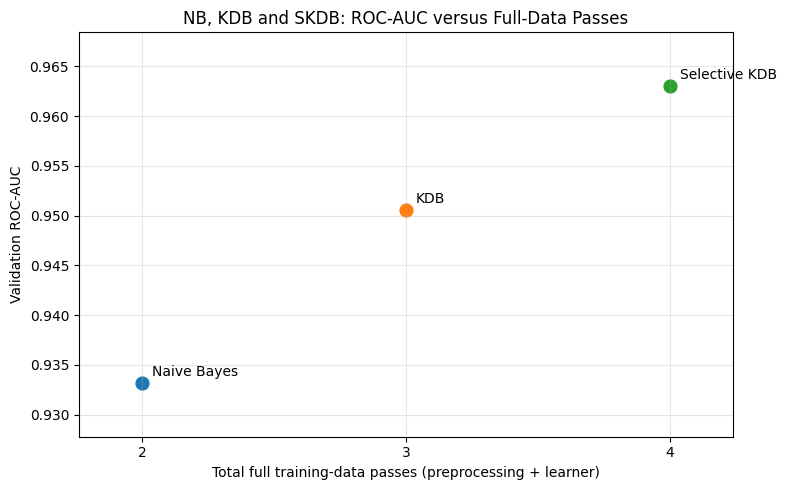

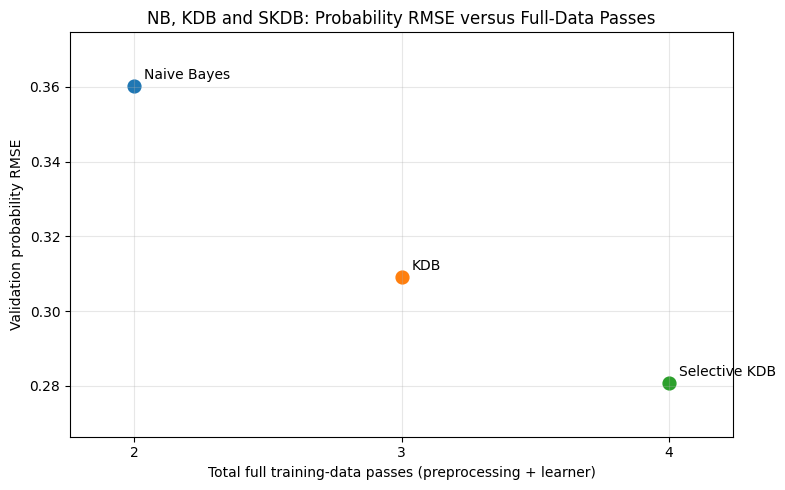

In [28]:
if not bayesian_results_df.empty:
    for metric, y_label, title, filename in [
        (
            "roc_auc",
            f"{EVALUATION_SPLIT.title()} ROC-AUC",
            "NB, KDB and SKDB: ROC-AUC versus Full-Data Passes",
            "bayesian_roc_auc_vs_full_passes.png",
        ),
        (
            "probability_rmse",
            f"{EVALUATION_SPLIT.title()} probability RMSE",
            "NB, KDB and SKDB: Probability RMSE versus Full-Data Passes",
            "bayesian_probability_rmse_vs_full_passes.png",
        ),
    ]:
        plt.figure(figsize=(8, 5))
        for result in bayesian_results_df.itertuples(index=False):
            y_value = getattr(result, metric)
            plt.scatter(result.total_data_passes, y_value, s=85)
            plt.annotate(
                result.model,
                (result.total_data_passes, y_value),
                xytext=(7, 5),
                textcoords="offset points",
            )

        plt.xlabel(
            "Total full training-data passes "
            "(preprocessing + learner)"
        )
        plt.ylabel(y_label)
        plt.title(title)
        plt.xticks(
            sorted(bayesian_results_df["total_data_passes"].unique())
        )
        plt.margins(x=0.12, y=0.18)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            Path("Skin dataset outputs") / filename,
            dpi=160,
            bbox_inches="tight",
        )
        plt.show()


## Hoeffding Tree versus NB versus KDB versus SKDB

The existing Hoeffding Tree checkpoints use genuine complete stream traversals, so they can share this axis. RF tree counts and XGBoost rounds are deliberately not included because those were nominal algorithm-native units rather than verified full-data passes.


,model,total_data_passes,roc_auc,probability_rmse,total_pipeline_training_seconds,evaluation_split,result_kind
0,Hoeffding Tree,1,0.687026,0.392473,1.669559,validation,pass checkpoint
1,Hoeffding Tree,2,0.687026,0.392473,3.223447,validation,pass checkpoint
2,Hoeffding Tree,3,0.687026,0.392473,4.685683,validation,pass checkpoint
3,Hoeffding Tree,4,0.687026,0.392472,6.048858,validation,pass checkpoint
4,Hoeffding Tree,5,0.687026,0.392472,7.410956,validation,pass checkpoint
5,Hoeffding Tree,6,0.687026,0.392472,8.796254,validation,pass checkpoint
6,Hoeffding Tree,7,0.687026,0.392472,10.171739,validation,pass checkpoint
7,Hoeffding Tree,8,0.687026,0.392472,11.436577,validation,pass checkpoint
8,Hoeffding Tree,9,0.687026,0.392472,12.903784,validation,pass checkpoint
9,Hoeffding Tree,10,0.687026,0.392472,14.537684,validation,pass checkpoint


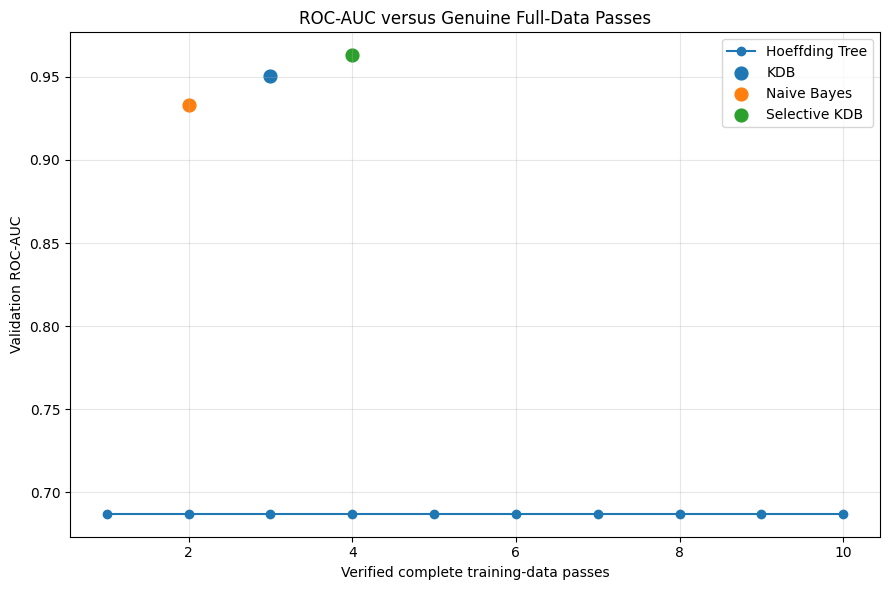

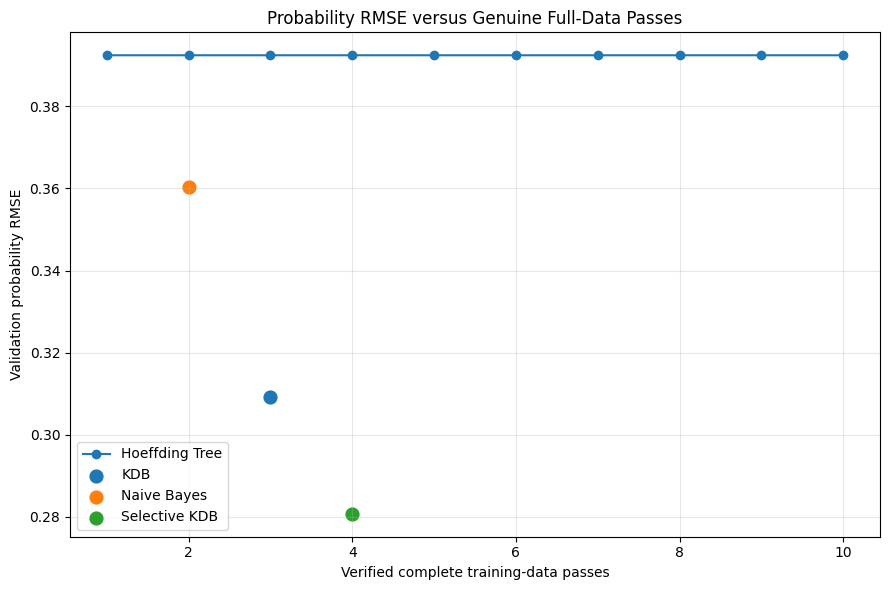

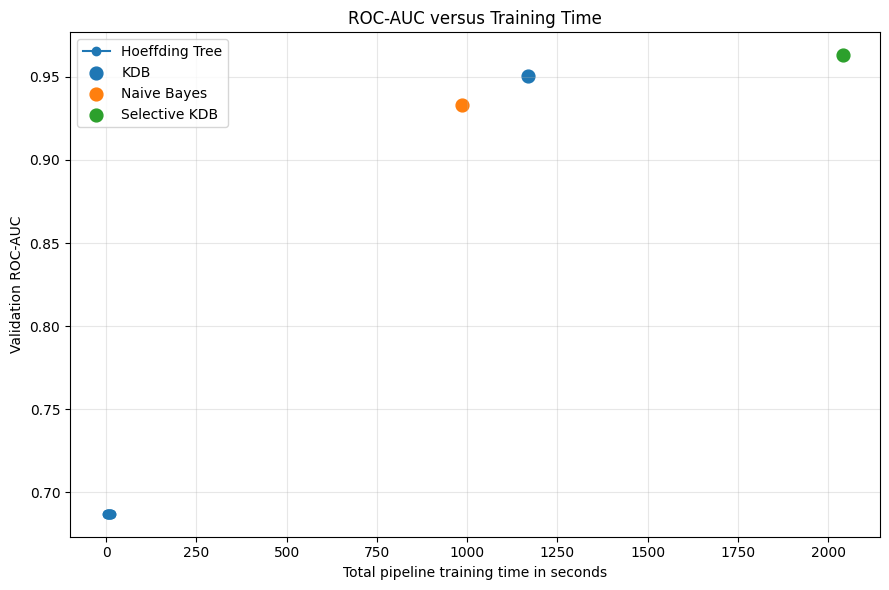

In [29]:
genuine_pass_comparison_df = pd.DataFrame()

if not bayesian_results_df.empty and EVALUATION_SPLIT == "validation":
    ht_genuine_pass_df = ht_pass_results_df[
        [
            "model",
            "pass",
            "roc_auc",
            "probability_rmse",
            "cumulative_training_seconds",
        ]
    ].copy()
    ht_genuine_pass_df = ht_genuine_pass_df.rename(
        columns={
            "pass": "total_data_passes",
            "cumulative_training_seconds":
                "total_pipeline_training_seconds",
        }
    )
    ht_genuine_pass_df["evaluation_split"] = "validation"
    ht_genuine_pass_df["result_kind"] = "pass checkpoint"

    bayesian_genuine_pass_df = bayesian_results_df[
        [
            "model",
            "total_data_passes",
            "roc_auc",
            "probability_rmse",
            "total_pipeline_training_seconds",
            "evaluation_split",
        ]
    ].copy()
    bayesian_genuine_pass_df["result_kind"] = "completed model"

    genuine_pass_comparison_df = pd.concat(
        [ht_genuine_pass_df, bayesian_genuine_pass_df],
        ignore_index=True,
    )
    genuine_pass_comparison_df.to_csv(
        Path("Skin dataset outputs")
        / "genuine_full_pass_comparison.csv",
        index=False,
    )
    display(genuine_pass_comparison_df)

    combined_plots = [
        (
            "roc_auc",
            "Validation ROC-AUC",
            "ROC-AUC versus Genuine Full-Data Passes",
            "all_models_roc_auc_vs_full_passes.png",
        ),
        (
            "probability_rmse",
            "Validation probability RMSE",
            "Probability RMSE versus Genuine Full-Data Passes",
            "all_models_probability_rmse_vs_full_passes.png",
        ),
    ]

    for metric, y_label, title, filename in combined_plots:
        plt.figure(figsize=(9, 6))
        for model_name, group in genuine_pass_comparison_df.groupby(
            "model"
        ):
            group = group.sort_values("total_data_passes")
            if model_name == "Hoeffding Tree":
                plt.plot(
                    group["total_data_passes"],
                    group[metric],
                    marker="o",
                    label=model_name,
                )
            else:
                plt.scatter(
                    group["total_data_passes"],
                    group[metric],
                    s=85,
                    label=model_name,
                )

        plt.xlabel("Verified complete training-data passes")
        plt.ylabel(y_label)
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            Path("Skin dataset outputs") / filename,
            dpi=160,
            bbox_inches="tight",
        )
        plt.show()

    plt.figure(figsize=(9, 6))
    for model_name, group in genuine_pass_comparison_df.groupby("model"):
        group = group.sort_values("total_pipeline_training_seconds")
        if model_name == "Hoeffding Tree":
            plt.plot(
                group["total_pipeline_training_seconds"],
                group["roc_auc"],
                marker="o",
                label=model_name,
            )
        else:
            plt.scatter(
                group["total_pipeline_training_seconds"],
                group["roc_auc"],
                s=85,
                label=model_name,
            )

    plt.xlabel("Total pipeline training time in seconds")
    plt.ylabel("Validation ROC-AUC")
    plt.title("ROC-AUC versus Training Time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        Path("Skin dataset outputs")
        / "all_models_roc_auc_vs_training_time.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
elif not bayesian_results_df.empty:
    print(
        "Combined HT plot skipped because the existing HT records are "
        "validation results and cannot be mixed with final-test results."
    )
